In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [8]:
import os

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModelAndWeights


DATA_DIR = os.getenv('DATA_DIR')
TRAINING_DIR = os.getenv('TRAINING_DIR')

config = Configuration(os.path.join(TRAINING_DIR, 'paraff/20241201-midiseq-paraff-se-ly+cc-d256-l8-dw0.02'), volatile=True)
#train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
model, chk = loadModelAndWeights(config, config['best'], postfix='JitEnc')
model.eval()
model


/home/camus/work/deep-starry/tests/../starry/utils/model_factory.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config.localPath(checkpoint_nam

SeqShareSEJitEnc(
  (word_emb): Embedding(324, 256, padding_idx=0)
  (word_prj): Linear(in_features=256, out_features=324, bias=False)
  (latent_prj): Linear(in_features=256, out_features=256, bias=False)
  (latent_emb): Linear(in_features=256, out_features=256, bias=True)
  (position_enc): PositionalEncoding()
  (layer_norm): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
  (attention): AttentionStack(
    (layer_stack): ModuleList(
      (0-7): 8 x EncoderLayer(
        (slf_attn): MultiHeadAttention(
          (w_qs): Linear(in_features=256, out_features=256, bias=False)
          (w_ks): Linear(in_features=256, out_features=256, bias=False)
          (w_vs): Linear(in_features=256, out_features=256, bias=False)
          (fc): Linear(in_features=256, out_features=256, bias=False)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (layer_norm): LayerNor

In [11]:
data, = loadDataset(config, data_dir=DATA_DIR, device='cpu', splits='0/1')
it = iter(data)

batch = next(it)
batch

{'summary': tensor([[-2.5298,  1.6278,  0.0395,  ...,  1.5188,  0.7176, -0.5361],
         [-0.1944, -0.2191,  1.0774,  ...,  0.2244,  0.9405, -0.0376],
         [-0.0740,  0.2298,  1.0851,  ...,  0.5501,  0.9526,  0.0495],
         ...,
         [ 0.4895, -0.3866,  0.0041,  ..., -0.3841,  1.0066, -1.3180],
         [ 0.8397, -0.7017,  0.7362,  ...,  0.0905,  0.7233, -0.5663],
         [ 0.8029, -0.6188,  0.5121,  ..., -0.0517,  0.0996,  0.1564]]),
 'seq': tensor([[  1,   2, 297,  ...,   0,   0,   0],
         [  1,   2, 122,  ...,   0,   0,   0],
         [  1,   2, 138,  ...,   0,   0,   0],
         ...,
         [  1,   2, 212,  ...,   0,   0,   0],
         [  1,   2,  54,  ...,   0,   0,   0],
         [  1,   2, 137,  ...,   0,   0,   0]]),
 'decoding_mask': tensor([[ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         ...,
         [ True,  True,  True,  ..

In [12]:
batch['seq'].shape

torch.Size([48, 235])

In [24]:
import torch


with torch.no_grad():
	sums = model(batch['seq'])

sums.shape

torch.Size([48, 256])

In [25]:
sums_norm = sums / sums.norm(dim=-1).unsqueeze(-1)
sums_norm.shape

torch.Size([48, 256])

In [26]:
target = batch['summary']
target_norm = target / target.norm(dim=-1).unsqueeze(-1)
target_norm.shape

torch.Size([48, 256])

In [27]:
product = torch.matmul(sums_norm, target_norm.transpose(0, 1))
product.shape

torch.Size([48, 48])

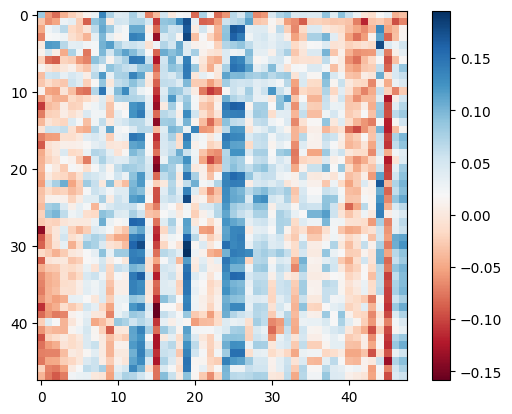

In [28]:
from matplotlib import pyplot as plt
%matplotlib inline


plt.imshow(product, cmap='RdBu')
plt.colorbar()
plt.show()